In [ ]:
%pip install -q pyteomics lxml

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys
REPO_DIR = "/content/drive/MyDrive/peptide-diffusion"
DATA_DIR = os.path.join(REPO_DIR, "Data", "E coli EV proteomics")
CKPT_DIR = os.path.join(REPO_DIR, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)

sys.path.insert(0, os.path.join(REPO_DIR, "src"))

print("Repo:", REPO_DIR)
print("Data:", DATA_DIR)
print("Files:", os.listdir(DATA_DIR) if os.path.exists(DATA_DIR) else "NOT FOUND")

In [1]:
# 03. Baseline Model Training and Evaluation
import os, sys, glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure src is on path (works whether cell 1 ran first or not)
REPO_DIR = "/content/drive/MyDrive/peptide-diffusion"
sys.path.insert(0, os.path.join(REPO_DIR, "src"))

from preprocessing import build_dataset, VOCAB, CHAR_TO_IDX
from baseline import PeptideDataset, Encoder, Decoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


/Users/akshaymohanrevankar/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-fq87h_0o because there was an issue with the default path (/Users/akshaymohanrevankar/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


Using device: mps


In [2]:
# Configuration
mzml_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.mzML")))
xlsx_paths = sorted(glob.glob(os.path.join(DATA_DIR, "Database search output*.xlsx")))
print("mzML:", mzml_paths)
print("xlsx:", xlsx_paths)


In [3]:
# 1. Load Data — both E. coli EV files
Xs, ys = [], []
for mzml, xlsx in zip(mzml_paths, xlsx_paths):
    Xi, yi = build_dataset(mzml, xlsx, max_spectra=2000)
    Xs.append(Xi); ys.append(yi)
X = np.concatenate(Xs)
y = np.concatenate(ys)
print(f"Dataset shape: X={X.shape}, y={y.shape}")


Building dataset... (This extracts and preprocesses up to 2000 spectra)


Dataset shape: X=(1488, 20000), y=(1488, 32)


In [4]:
# 2. Train/Val/Test Split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {len(X_train)}  Val size: {len(X_val)}  Test size: {len(X_test)}")

batch_size = 32
train_loader = DataLoader(PeptideDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(PeptideDataset(X_val, y_val), batch_size=batch_size)
test_loader = DataLoader(PeptideDataset(X_test, y_test), batch_size=batch_size)


Train size: 1041  Val size: 223  Test size: 224


In [5]:
# 3. Model Logic
class BaselineModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        
    def forward(self, src, trg):
        context = self.encoder(src)
        out = self.decoder(trg, context)
        return out

def calc_aa_recall(preds, targets):
    pred_classes = preds.argmax(dim=-1)
    mask = targets > 2 # ignore PAD(0), SOS(1), EOS(2)
    correct = (pred_classes == targets) & mask
    if mask.sum().item() == 0:
        return 0.0, 0
    return correct.sum().item(), mask.sum().item()

def calc_peptide_acc(preds, targets):
    pred_classes = preds.argmax(dim=-1)
    # Peptide accuracy: all tokens from first to EOS match
    acc_count = 0
    for i in range(targets.size(0)):
        p = pred_classes[i]
        t = targets[i]
        # Compare until EOS or PAD
        mask = t > 2
        if mask.sum() > 0 and torch.equal(p[mask], t[mask]):
            acc_count += 1
    return acc_count


In [6]:
# 4. Train LSTM Baseline (15 Epochs)
encoder_lstm = Encoder(input_dim=20000, context_dim=256)
decoder_lstm = Decoder(vocab_size=23, embed_dim=64, hidden_dim=256, context_dim=256, num_layers=2)
model_lstm = BaselineModel(encoder_lstm, decoder_lstm).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=1e-3, weight_decay=1e-5)

epochs = 15
lstm_train_losses = []
lstm_val_losses = []
lstm_val_recalls = []

best_val_loss = float('inf')
os.makedirs(CKPT_DIR, exist_ok=True)

print("--- Training LSTM Baseline ---")
for epoch in range(epochs):
    model_lstm.train()
    epoch_loss = 0
    for src, trg in train_loader:
        src, trg = src.to(device), trg.to(device)
        optimizer_lstm.zero_grad()
        
        trg_input = trg[:, :-1]
        trg_target = trg[:, 1:]
        
        output = model_lstm(src, trg_input)
        loss = criterion(output.reshape(-1, output.shape[-1]), trg_target.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=1.0)
        optimizer_lstm.step()
        epoch_loss += loss.item()
        
    train_loss = epoch_loss / len(train_loader)
    lstm_train_losses.append(train_loss)
    
    # Validation
    model_lstm.eval()
    val_loss = 0
    correct_aa = 0
    total_aa = 0
    
    with torch.no_grad():
        for src, trg in val_loader:
            src, trg = src.to(device), trg.to(device)
            trg_input = trg[:, :-1]
            trg_target = trg[:, 1:]
            
            output = model_lstm(src, trg_input)
            loss = criterion(output.reshape(-1, output.shape[-1]), trg_target.reshape(-1))
            val_loss += loss.item()
            
            c, t = calc_aa_recall(output, trg_target)
            correct_aa += c
            total_aa += t
            
    val_loss /= len(val_loader)
    val_recall = correct_aa / total_aa if total_aa > 0 else 0
    
    lstm_val_losses.append(val_loss)
    lstm_val_recalls.append(val_recall)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AA Recall: {val_recall:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_lstm.state_dict(), os.path.join(CKPT_DIR, "lstm_best.pt"))


--- Training LSTM Baseline ---


2026-03-29 13:16:23.731 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_23-1943633382‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:23.781 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_23-1106337212‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:23.827 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_23-3513750862‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-29 13:16:24.135 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_24-1182688068‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:24.138 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_24-2631564007‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:24.243 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_24-689734483‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:24.332 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_24-334701219‚Äù in the folder ‚Äúcom.apple

2026-03-29 13:16:24.393 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_24-2238471588‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:24.445 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_24-482028777‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-29 13:16:25.058 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_25-4022687490‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


...

Epoch 11/15 | Train Loss: 2.3613 | Val Loss: 2.5579 | Val AA Recall: 0.2117


Epoch 12/15 | Train Loss: 2.2891 | Val Loss: 2.5329 | Val AA Recall: 0.2312


Epoch 13/15 | Train Loss: 2.2166 | Val Loss: 2.5206 | Val AA Recall: 0.2544


Epoch 14/15 | Train Loss: 2.1239 | Val Loss: 2.4564 | Val AA Recall: 0.2863


Epoch 15/15 | Train Loss: 2.0184 | Val Loss: 2.4372 | Val AA Recall: 0.3126


In [7]:
# 5. GRU Ablation Study
class DecoderGRU(nn.Module):
    def __init__(self, vocab_size=23, embed_dim=64, hidden_dim=256, context_dim=256, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(input_size=embed_dim + context_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
    def forward(self, trg, context):
        embedded = self.embedding(trg)
        seq_len = trg.shape[1]
        context_repeated = context.unsqueeze(1).repeat(1, seq_len, 1)
        rnn_input = torch.cat((embedded, context_repeated), dim=2)
        outputs, _ = self.rnn(rnn_input)
        return self.fc_out(outputs)

encoder_gru = Encoder(input_dim=20000, context_dim=256)
decoder_gru = DecoderGRU(vocab_size=23, embed_dim=64, hidden_dim=256, context_dim=256, num_layers=2)
model_gru = BaselineModel(encoder_gru, decoder_gru).to(device)

optimizer_gru = optim.Adam(model_gru.parameters(), lr=1e-3, weight_decay=1e-5)

gru_train_losses = []
gru_val_losses = []
best_gru_val_loss = float("inf")

print("\n--- Training GRU Ablation ---")
for epoch in range(epochs):
    model_gru.train()
    epoch_loss = 0
    for src, trg in train_loader:
        src, trg = src.to(device), trg.to(device)
        optimizer_gru.zero_grad()
        output = model_gru(src, trg[:, :-1])
        loss = criterion(output.reshape(-1, output.shape[-1]), trg[:, 1:].reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model_gru.parameters(), max_norm=1.0)
        optimizer_gru.step()
        epoch_loss += loss.item()
    gru_train_losses.append(epoch_loss / len(train_loader))
    
    model_gru.eval()
    val_loss = 0
    with torch.no_grad():
        for src, trg in val_loader:
            src, trg = src.to(device), trg.to(device)
            output = model_gru(src, trg[:, :-1])
            loss = criterion(output.reshape(-1, output.shape[-1]), trg[:, 1:].reshape(-1))
            val_loss += loss.item()
    gru_val_losses.append(val_loss / len(val_loader))
    if gru_val_losses[-1] < best_gru_val_loss:
        best_gru_val_loss = gru_val_losses[-1]
        torch.save(model_gru.state_dict(), os.path.join(CKPT_DIR, "gru_best.pt"))

gru_train_loss_final = gru_train_losses[-1]
gru_val_loss_final   = gru_val_losses[-1]
print(f"GRU final | Train Loss: {gru_train_loss_final:.4f} | Val Loss: {gru_val_loss_final:.4f}")



--- Training GRU Ablation ---


2026-03-29 13:16:45.216 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_45-62721655‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:45.321 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_45-2853553400‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:45.329 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_45-2046063203‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:45.332 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_45-1839763753‚Äù in the folder ‚Äúcom.apple

2026-03-29 13:16:45.418 python[86303:3549847] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_45-3614887627‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:45.477 python[86303:3549847] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_45-4269502790‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:45.532 python[86303:3549847] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_45-3135002006‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:45.535 python[86303:3549847] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_45-2580248252‚Äù in the folder ‚Äúcom.app

2026-03-29 13:16:45.623 python[86303:3549847] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_45-421664541‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:45.625 python[86303:3549847] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_45-4287620080‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:45.639 python[86303:3549847] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_45-938636835‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:45.643 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_45-1046318702‚Äù in the folder ‚Äúcom.apple

2026-03-29 13:16:47.142 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_47-437517180‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:47.224 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_47-913707945‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:47.230 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_47-3404081976‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:47.233 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_47-1881290569‚Äù in the folder ‚Äúcom.apple

2026-03-29 13:16:47.417 python[86303:3549847] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_47-34759926‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:47.419 python[86303:3549847] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_47-3545306935‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:47.433 python[86303:3549847] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_47-819871348‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:16:47.522 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_16_47-1654538558‚Äù in the folder ‚Äúcom.apple.

GRU final | Train Loss: 1.4938 | Val Loss: 2.2379


In [8]:
# --- Helper: Evaluate model on test set ---
IDX_TO_CHAR = {v: k for k, v in CHAR_TO_IDX.items()}

def decode_seq(tokens):
    out = []
    for t in tokens:
        t = int(t)
        if t == 2: break
        if t >= 3: out.append(IDX_TO_CHAR.get(t, "?"))
    return "".join(out)

def evaluate_test(model):
    model.eval()
    correct_aa, total_aa, correct_pep, total_pep = 0, 0, 0, 0
    all_preds, all_targs = [], []
    pred_seqs, true_seqs = [], []
    with torch.no_grad():
        for src, trg in test_loader:
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg[:, :-1])
            preds   = output.argmax(dim=-1)
            targets = trg[:, 1:]
            mask = targets > 2
            correct_aa  += ((preds == targets) & mask).sum().item()
            total_aa    += mask.sum().item()
            correct_pep += ((preds == targets) | ~mask).all(dim=1).sum().item()
            total_pep   += targets.size(0)
            all_preds.append(preds.cpu())
            all_targs.append(targets.cpu())
            for p, t in zip(preds.cpu(), targets.cpu()):
                pred_seqs.append(decode_seq(p))
                true_seqs.append(decode_seq(t))
    aa_recall = correct_aa / max(total_aa, 1)
    pep_acc   = correct_pep / max(total_pep, 1)
    return aa_recall, pep_acc, torch.cat(all_preds), torch.cat(all_targs), pred_seqs, true_seqs


In [9]:
# 6. Test Evaluation & Final Metrics
lstm_test_recall, lstm_test_pep_acc, lstm_preds, lstm_targs, lstm_pred_seqs, lstm_true_seqs = evaluate_test(model_lstm)
gru_test_recall,  gru_test_pep_acc,  _,          _,          gru_pred_seqs,  gru_true_seqs  = evaluate_test(model_gru)

import pandas as pd, os
RESULTS_DIR = os.path.join(REPO_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Results / ablation table ─────────────────────────────────────────────
results = pd.DataFrame([
    {"Model": "LSTM Baseline",
     "Train Loss": round(lstm_train_losses[-1], 4),
     "Val Loss":   round(lstm_val_losses[-1], 4),
     "AA Recall %": round(lstm_test_recall * 100, 2),
     "Pep Acc %":  round(lstm_test_pep_acc * 100, 2)},
    {"Model": "GRU Ablation",
     "Train Loss": round(gru_train_losses[-1], 4),
     "Val Loss":   round(gru_val_losses[-1], 4),
     "AA Recall %": round(gru_test_recall * 100, 2),
     "Pep Acc %":  round(gru_test_pep_acc * 100, 2)},
])
print(results.to_string(index=False))
results.to_csv(os.path.join(RESULTS_DIR, "baseline_ablation_results.csv"), index=False)
print("Saved baseline_ablation_results.csv")

# ── Predicted sequences CSV ──────────────────────────────────────────────
lstm_df = pd.DataFrame({"true_sequence": lstm_true_seqs, "predicted_sequence": lstm_pred_seqs,
                         "correct": [p == t for p, t in zip(lstm_pred_seqs, lstm_true_seqs)]})
lstm_df.to_csv(os.path.join(RESULTS_DIR, "lstm_predictions.csv"), index=False)
print(f"Saved lstm_predictions.csv  ({len(lstm_df)} sequences)")

gru_df = pd.DataFrame({"true_sequence": gru_true_seqs, "predicted_sequence": gru_pred_seqs,
                        "correct": [p == t for p, t in zip(gru_pred_seqs, gru_true_seqs)]})
gru_df.to_csv(os.path.join(RESULTS_DIR, "gru_predictions.csv"), index=False)
print(f"Saved gru_predictions.csv   ({len(gru_df)} sequences)")


2026-03-29 13:17:11.110 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_11-467194652‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.



=== Final Metrics Table ===
Model Variant  Train Loss (Final)  Val Loss (Final)  Test AA Recall (%)  Test Peptide Acc (%)
LSTM Baseline              2.0184            2.4372               31.51                  2.68
 GRU Ablation              1.4938            2.2379               44.30                  6.70


2026-03-29 13:17:11.412 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_11-346467304‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-29 13:17:11.553 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_11-3856158129‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-29 13:17:11.637 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_11-2529373223‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:17:11.640 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_11-2300917164‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:17:11.721 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_11-1829117455‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-29 13:17:11.887 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_11-3923969037‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-29 13:17:13.733 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_13-2718303851‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:17:13.815 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_13-1406186158‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:17:13.822 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_13-643685284‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:17:13.825 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_13-1582543973‚Äù in the folder ‚Äúcom.appl

2026-03-29 13:17:13.992 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_13-2464542509‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:17:13.994 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_13-2155011190‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:17:14.020 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_14-3468898644‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:17:14.022 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_14-3844308220‚Äù in the folder ‚Äúcom.app

2026-03-29 13:17:14.212 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_14-1449475574‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-29 13:17:14.215 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_14-3965574361‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
/tmp/ipykernel_86303/4191667825.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = df_err.groupby('Bucket')['Recall'].mean()


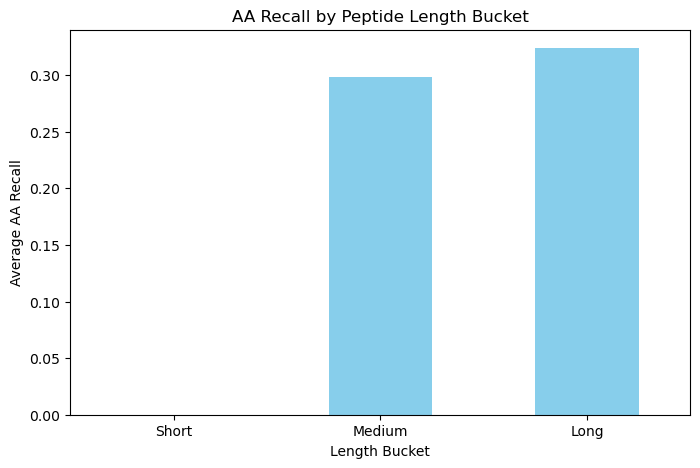

Analysis saved to /tmp/peptide_outputs/figures/eda/aa_recall_by_length.png


In [10]:
# Error Analysis: AA Recall by Peptide Length Bucket
def analyze_by_length(targets, preds):
    results = {'Short (3-5)': [], 'Medium (6-10)': [], 'Long (10+)': []}
    # Flatten lists of sequences
    # Wait, targets and preds from evaluate_test are flattened lists of tokens.
    # We need sequence-level recall.
    pass

# Better implementation for analysis
lengths = []
recalls = []
with torch.no_grad():
    for src, trg in test_loader:
        src, trg = src.to(device), trg.to(device)
        output = model_lstm(src, trg[:, :-1])
        pred_classes = output.argmax(dim=-1)
        for j in range(trg.size(0)):
            t = trg[j, 1:]
            p = pred_classes[j]
            mask = t > 2
            if mask.sum() > 0:
                correct = (p[mask] == t[mask]).sum().item()
                total = mask.sum().item()
                lengths.append(total)
                recalls.append(correct / total)

df_err = pd.DataFrame({'Length': lengths, 'Recall': recalls})
df_err['Bucket'] = pd.cut(df_err['Length'], bins=[0, 5, 10, 50], labels=['Short', 'Medium', 'Long'])
bucket_stats = df_err.groupby('Bucket')['Recall'].mean()

plt.figure(figsize=(8, 5))
bucket_stats.plot(kind='bar', color='skyblue')
plt.title('AA Recall by Peptide Length Bucket')
plt.ylabel('Average AA Recall')
plt.xlabel('Length Bucket')
plt.xticks(rotation=0)
plt.savefig('../figures/eda/aa_recall_by_length.png')
plt.show()
print("Analysis saved to ../figures/eda/aa_recall_by_length.png")


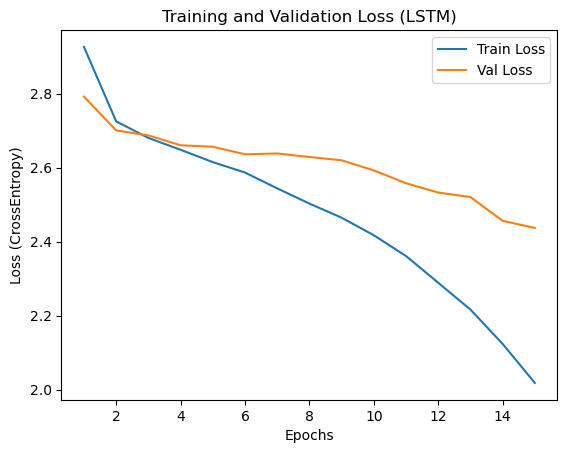

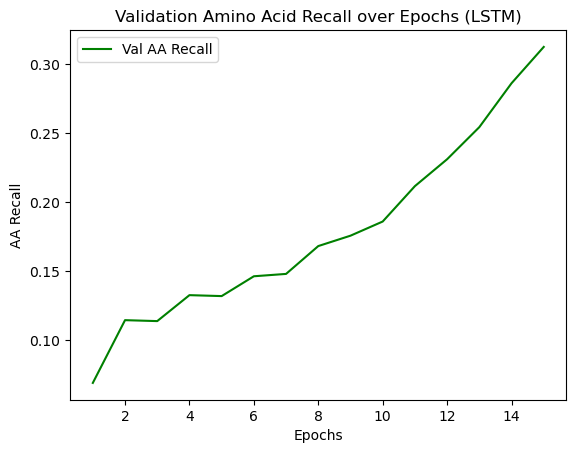

In [11]:
# 7. Plots (Loss and AA Recall Curves)
plt.figure()
plt.plot(range(1, epochs+1), lstm_train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), lstm_val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (CrossEntropy)')
plt.title('Training and Validation Loss (LSTM)')
plt.legend()
plt.savefig('../figures/eda/training_loss.png')
plt.show()

plt.figure()
plt.plot(range(1, epochs+1), lstm_val_recalls, color='green', label='Val AA Recall')
plt.xlabel('Epochs')
plt.ylabel('AA Recall')
plt.title('Validation Amino Acid Recall over Epochs (LSTM)')
plt.legend()
plt.savefig('../figures/eda/aa_recall_curve.png')
plt.show()


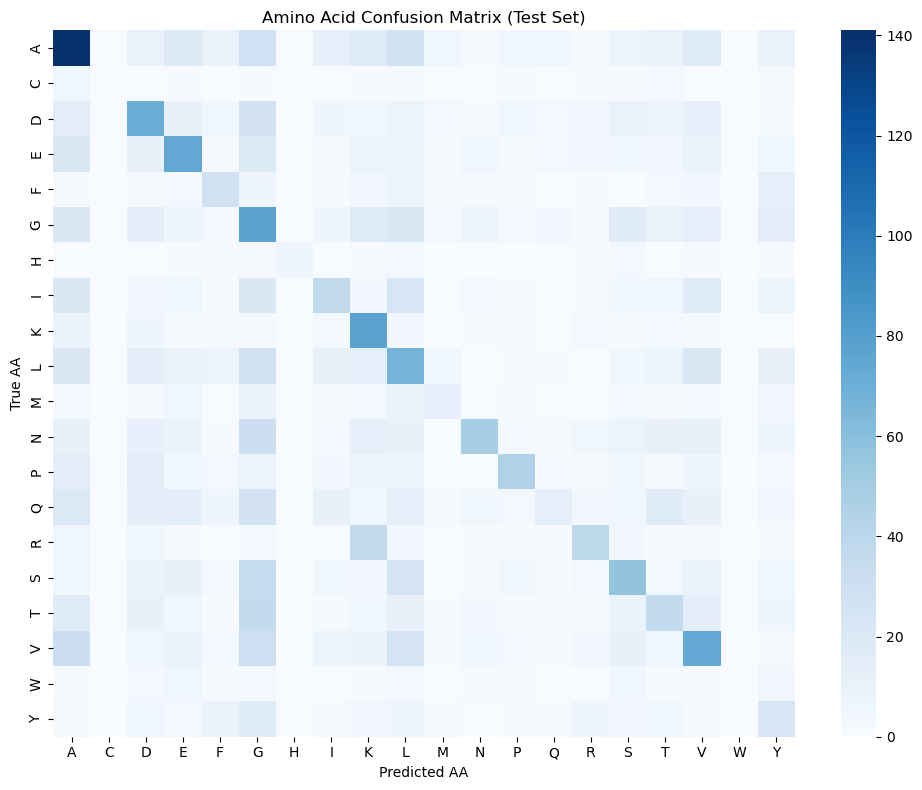

In [12]:
# 8. Confusion Matrix over Amino Acids
cm = confusion_matrix(lstm_targs.flatten(), lstm_preds.flatten(), labels=range(3, 23))

# Label names
labels = [VOCAB[i-3] for i in range(3, 23)]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Amino Acid Confusion Matrix (Test Set)")
plt.xlabel("Predicted AA")
plt.ylabel("True AA")
plt.tight_layout()
plt.savefig('../figures/eda/confusion_matrix.png')
plt.show()


In [13]:
# 9. 10 Prediction Examples
IDX_TO_CHAR = {v: k for k, v in CHAR_TO_IDX.items()}
IDX_TO_CHAR[0] = ''
IDX_TO_CHAR[1] = '<SOS>'
IDX_TO_CHAR[2] = '<EOS>'

def decode_sequence(tokens):
    return "".join([IDX_TO_CHAR.get(t.item(), "") if isinstance(t, torch.Tensor) else IDX_TO_CHAR.get(t, "") for t in tokens if t not in [0, 1, 2]])

print("\n--- 10 Prediction Examples (LSTM Baseline) ---")
with torch.no_grad():
    count = 0
    for src, trg in test_loader:
        src, trg = src.to(device), trg.to(device)
        output = model_lstm(src, trg[:, :-1])
        preds = output.argmax(dim=-1)
        
        for i in range(preds.size(0)):
            pred_seq = decode_sequence(preds[i])
            true_seq = decode_sequence(trg[i, 1:])
            print(f"Ground Truth: {true_seq:15s} | Predicted: {pred_seq:15s}")
            count += 1
            if count == 10:
                break
        if count == 10: break



--- 10 Prediction Examples (LSTM Baseline) ---
Ground Truth: AVAAGMNPMDLK    | Predicted: AGVESMVRKKKKKKKKKKKKKKKKKKKKKK
Ground Truth: MIQEQTMLNVADNSGAR | Predicted: GIDMMGPDDEEEEGKRRVDKKKKKKKKKKK
Ground Truth: DDEVIVLTGK      | Predicted: GQALLTVNKKVVKKKKKKKKKKKKKKKKKK


2026-03-29 13:17:14.972 python[86303:3549342] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-86303-2026-03-29_13_17_14-2875924621‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


Ground Truth: DAQSALTVSETTFGR | Predicted: VVLLLTDGSYGYYGRVRRRRRRRRRRRRRR
Ground Truth: VDQLSNDVNAMR    | Predicted: VDQLSNDVNAMRRRKKKKKKKKKKKKKKKK
Ground Truth: TIVSDGKPQTDNDTGMISYK | Predicted: TIVSDGKPVTDDDTLMISYKVKKKKKKKKK
Ground Truth: VDQLSNDVNAMR    | Predicted: VDQLSNDVNAMRRRKKKKKKKKKKKKKKKK
Ground Truth: EISMSIK         | Predicted: GGGDGAARKKKKKKKKKKKKKKKKKKKKKK
Ground Truth: SLEQYFGR        | Predicted: GGGGFFGRRKKKKKKKKKKKKKKKKKKKKK


Ground Truth: SALVIQTLANGAVR  | Predicted: VAVGAAGAAEKKKKVKKKKKKKKKKKKKKK
